# 02 -- Exploratory Data Analysis

BuildGuard AI's synthetic construction portfolio (Section 8.2/8.4),
generated deterministically by `buildguard.data.synthetic.generate_portfolio`
from the seed in `configs/base.yaml`. No confidential or proprietary
project data is used anywhere in this repository
(`docs/DATA_PRIVACY.md`).

This notebook looks at the data itself, before any feature engineering or
modeling: portfolio composition, budget and EVM-ratio distributions, and
how often cost overruns/schedule delays actually occur in this portfolio.
Per the notebook policy (Section 34), it imports the project's own
functions rather than redefining logic, runs top-to-bottom
deterministically, and carries written conclusions. Figures are saved to
`reports/figures/`.

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from buildguard.config import PROJECT_ROOT, load_base_config
from buildguard.data.economic_index import DemoIndexProvider
from buildguard.data.labels import resolve_outcomes
from buildguard.data.synthetic import generate_portfolio
from buildguard.features import evm

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

cfg = load_base_config()
dataset = generate_portfolio(cfg)
print(f"seed={cfg.seed}, n_projects configured={cfg.synthetic_data.n_projects}")

seed=42, n_projects configured=400


## Dataset shape

Row counts and missing-value counts for all six core tables.

In [2]:
tables = {
    "projects": dataset.projects,
    "project_snapshots": dataset.snapshots,
    "work_packages": dataset.work_packages,
    "change_orders": dataset.change_orders,
    "suppliers": dataset.suppliers,
    "economic_index": dataset.economic_index,
}
pd.DataFrame(
    {name: [len(df), int(df.isna().sum().sum())] for name, df in tables.items()},
    index=["rows", "missing_values"],
).T

,rows,missing_values
projects,400,0
project_snapshots,11953,0
work_packages,19543,0
change_orders,897,0
suppliers,2972,0
economic_index,61,0


## Portfolio composition

How projects are distributed across type, construction standard, and state.

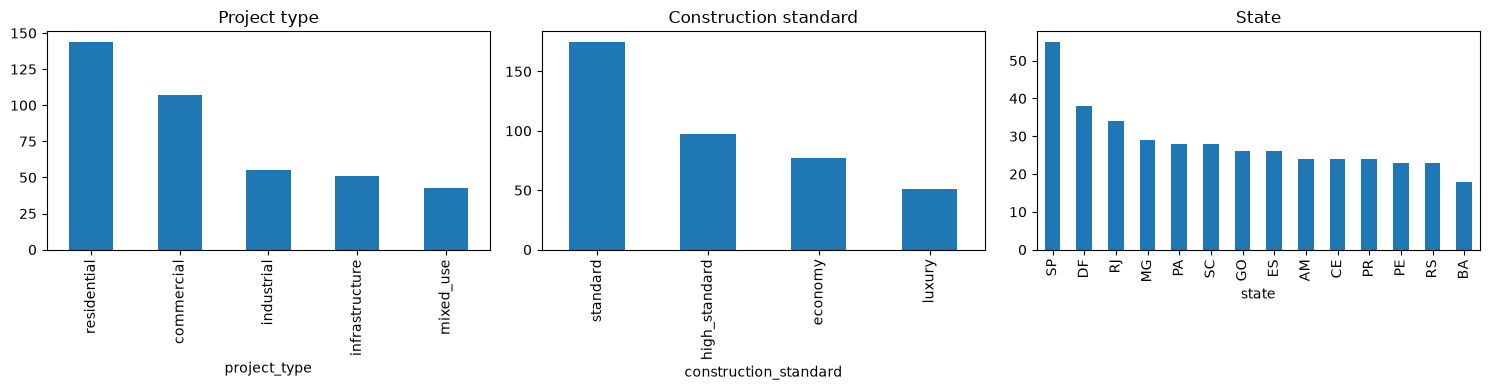

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
dataset.projects["project_type"].value_counts().plot.bar(ax=axes[0], title="Project type")
dataset.projects["construction_standard"].value_counts().plot.bar(
    ax=axes[1], title="Construction standard"
)
dataset.projects["state"].value_counts().plot.bar(ax=axes[2], title="State")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "portfolio_composition.png", dpi=120)
plt.show()

## Budget distribution

`approved_budget` is heavily right-skewed -- shown on both a linear and a log scale.

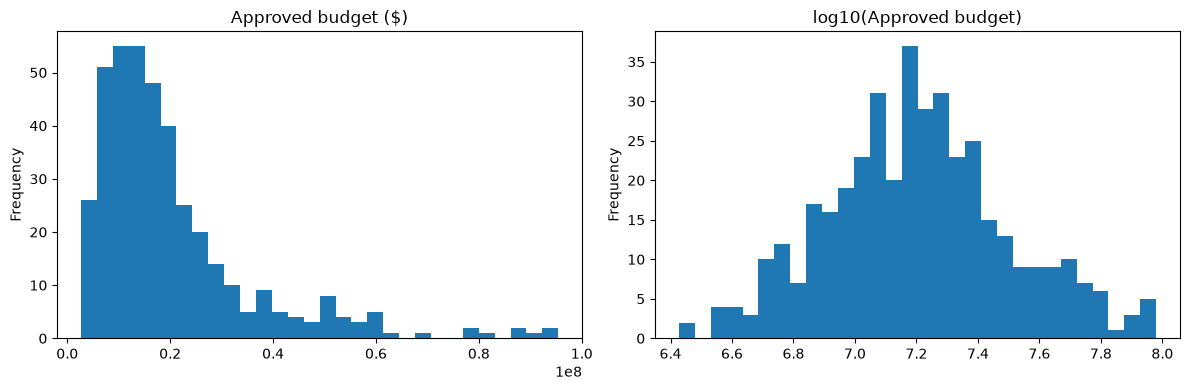

count    4.000000e+02
mean     2.041639e+07
std      1.596316e+07
min      2.674507e+06
25%      1.044744e+07
50%      1.588638e+07
75%      2.424146e+07
max      9.543331e+07
Name: approved_budget, dtype: float64

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
dataset.projects["approved_budget"].plot.hist(bins=30, ax=axes[0], title="Approved budget ($)")
np.log10(dataset.projects["approved_budget"]).plot.hist(
    bins=30, ax=axes[1], title="log10(Approved budget)"
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "budget_distribution.png", dpi=120)
plt.show()
dataset.projects["approved_budget"].describe()

## EVM ratios (CPI/SPI) across all snapshots

Computed with the project's own `buildguard.features.evm` functions -- not redefined here (Section 34). CPI/SPI = 1.0 (the red dashed line) is the on-plan boundary; below it signals cost/schedule strain.

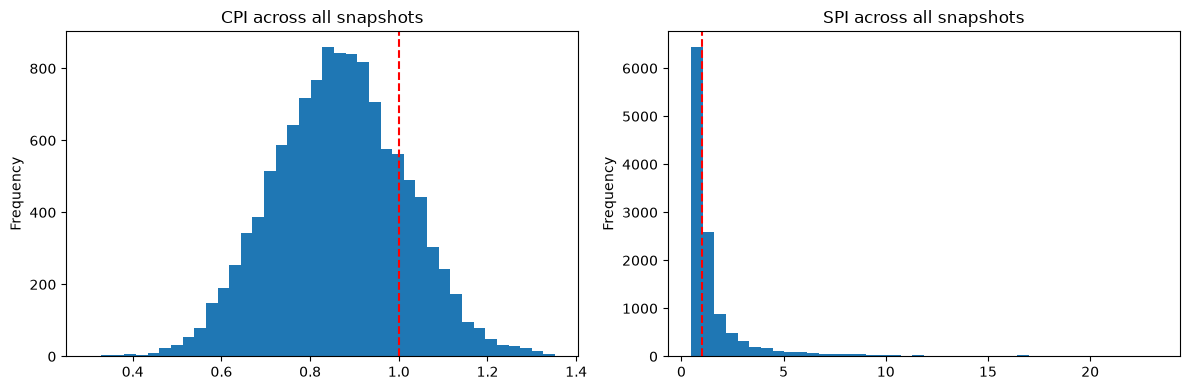

,cpi,spi
count,11953.000000,11953.000000
mean,0.864471,1.830082
std,0.147698,2.432447
min,0.302452,0.470001
25%,0.762626,0.875048
50%,0.864594,1.005737
75%,0.963640,1.578066
max,1.352512,23.256377


In [5]:
snaps = dataset.snapshots.copy()
snaps["cpi"] = evm.cost_performance_index(snaps["earned_value"], snaps["actual_cost"])
snaps["spi"] = evm.schedule_performance_index(snaps["earned_value"], snaps["planned_cost"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
snaps["cpi"].plot.hist(bins=40, ax=axes[0], title="CPI across all snapshots")
axes[0].axvline(1.0, color="red", linestyle="--")
snaps["spi"].plot.hist(bins=40, ax=axes[1], title="SPI across all snapshots")
axes[1].axvline(1.0, color="red", linestyle="--")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "cpi_spi_distribution.png", dpi=120)
plt.show()
snaps[["cpi", "spi"]].describe()

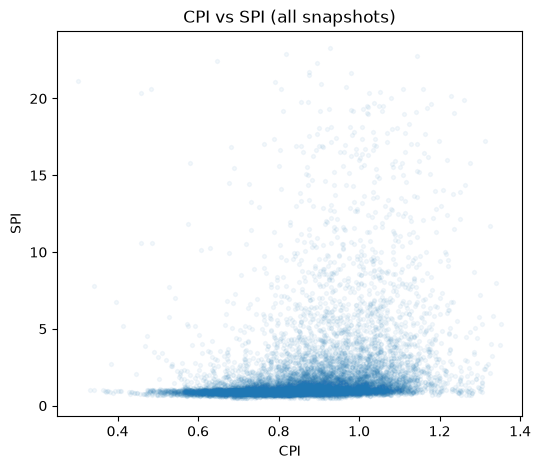

,cpi,spi
cpi,1.000000,0.270725
spi,0.270725,1.000000


In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(snaps["cpi"], snaps["spi"], alpha=0.05, s=8)
ax.set_xlabel("CPI")
ax.set_ylabel("SPI")
ax.set_title("CPI vs SPI (all snapshots)")
fig.savefig(FIGURES_DIR / "cpi_vs_spi.png", dpi=120)
plt.show()
snaps[["cpi", "spi"]].corr()

## Change orders

Category mix and the size distribution of approved change-order amounts.

In [7]:
dataset.change_orders["category"].value_counts()

category
scope_change      270
site_condition    188
design_error      162
client_request    143
regulatory         87
other              47
Name: count, dtype: int64

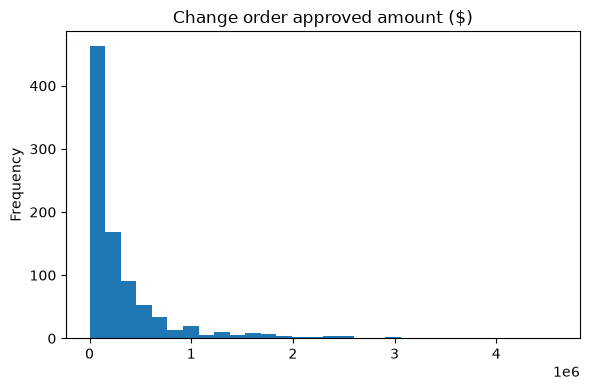

count    8.970000e+02
mean     3.139197e+05
std      5.050665e+05
min      0.000000e+00
25%      1.482226e+04
50%      1.433209e+05
75%      3.597383e+05
max      4.594054e+06
Name: approved_amount, dtype: float64

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
dataset.change_orders["approved_amount"].plot.hist(
    bins=30, ax=ax, title="Change order approved amount ($)"
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "change_order_amounts.png", dpi=120)
plt.show()
dataset.change_orders["approved_amount"].describe()

## Realized outcomes

Using the project's own label logic (`buildguard.data.labels.resolve_outcomes`, not redefined here) to see how often cost overruns and schedule delays actually happen among the projects that have already finished. In-flight projects (`is_resolved=False`) have no ground truth yet -- excluded, not coerced.

In [9]:
provider = DemoIndexProvider(
    reference_date=cfg.synthetic_data.reference_date,
    history_years=cfg.synthetic_data.history_years,
)
outcomes = resolve_outcomes(
    dataset.projects,
    dataset.snapshots,
    provider,
    cfg.targets.cost_overrun_tolerance,
    cfg.targets.schedule_delay_tolerance_days,
)
resolved = outcomes.loc[outcomes["is_resolved"]]
print(f"{len(resolved)} of {len(outcomes)} projects are resolved (completed)")
print(f"cost_overrun prevalence (resolved): {resolved['cost_overrun'].mean():.1%}")
print(f"schedule_delay prevalence (resolved): {resolved['schedule_delay'].mean():.1%}")

345 of 400 projects are resolved (completed)
cost_overrun prevalence (resolved): 47.0%
schedule_delay prevalence (resolved): 50.4%


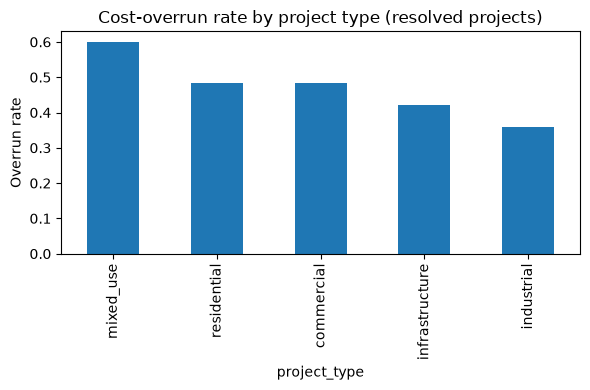

project_type
mixed_use              0.6
residential       0.483871
commercial        0.483516
infrastructure    0.422222
industrial            0.36
Name: cost_overrun, dtype: Float64

In [10]:
merged = resolved.merge(
    dataset.projects[["project_id", "project_type", "construction_standard"]],
    on="project_id",
)
overrun_by_type = merged.groupby("project_type")["cost_overrun"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(6, 4))
overrun_by_type.plot.bar(ax=ax, title="Cost-overrun rate by project type (resolved projects)")
ax.set_ylabel("Overrun rate")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "overrun_rate_by_type.png", dpi=120)
plt.show()
overrun_by_type

## Conclusions

Real findings from this run (seed=42, 400 projects, 11,953 snapshots) --
not modeling results, just what the raw data itself shows:

- **Clean data.** Zero missing values across all six tables. 400 projects,
  11,953 monthly snapshots, 19,543 work packages, 897 change orders, 2,972
  suppliers.
- **Budget is right-skewed**, as expected for a construction portfolio:
  median approved budget $15.9M, mean $20.4M, pulled up by a long tail
  (max $95.4M vs. min $2.7M) -- the log10 view is roughly symmetric,
  consistent with the lognormal-like process used to generate it.
- **CPI averages 0.86, below the 1.0 on-plan line** -- this portfolio
  skews toward cost pressure by construction, not by accident. **SPI
  averages 1.83 with a max of 23.3** -- SPI is well known to be unstable
  early in a project's life, when `planned_cost` (the denominator) is
  still near zero; this is an EVM ratio artifact, not a data defect, and
  is exactly why the feature pipeline's temporal/lifecycle features
  (`features/temporal.py`) exist alongside the raw ratios.
- **CPI and SPI are only weakly correlated (r = 0.27)** -- cost and
  schedule performance move mostly independently in this portfolio, so a
  project can run over budget without necessarily running late, or vice
  versa. This is why BuildGuard AI models cost-overrun and schedule-delay
  risk as two separate tasks rather than one combined "trouble" label.
- **Change orders are dominated by scope changes** (270 of 897, 30%),
  ahead of site conditions (188) and design errors (162). Approved amounts
  are right-skewed (median $143K, max $4.6M).
- **345 of 400 projects (86%) have already completed** in this snapshot of
  the portfolio; among those, **47.0% overran cost and 50.4% ran behind
  schedule** -- both far above a rare-event base rate, confirming these
  are genuinely hard, close-to-balanced classification problems rather
  than a trivial imbalanced one. Cost-overrun rate varies by `project_type`
  (60% for mixed-use vs. 36% for industrial) -- an early, purely
  descriptive hint that this column carries real signal, later confirmed
  by SHAP in `docs/adr/0010-evaluation-explainability-design.md`.